# Statistics and Data Analysis - Learning Notebook
----

# Contents

In this notebook we will cover the following:

1. Common pandas operations: **.unique**, **.value_counts**, **.where**
2. Common numerical operations with pandas: **.mean**, **.sum**, **.max**, **.idxmax**, **.min**, **.idxmin**, **.diff**
3. masking in pandas : the basics
4. plotting with pandas: **bar**, **line** and **histogram** plots
5. Dealing with NaNs.


# Imports

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Hospital-Da-Luz-Learning-Health/MLCatolica24/main/Aula%203%20-%20Data%20Analysis%20%26%20Statistics/Pandas%20DataFrames%20101/data/heart_disease_cleaned.csv').set_index('id')
df.head()
df.shape

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
192,43,male,asymptomatic,132,247,1,left ventricular hypertrophy,143,1,0.1,fat,NaN,reversible defect,>50%
189,69,male,non-anginal pain,140,254,0,left ventricular hypertrophy,146,0,2.0,fat,3.0,reversible defect,>50%
0,63,male,typical angina,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0.0,fixed defect,<50%
23,58,male,non-anginal pain,132,224,0,left ventricular hypertrophy,173,0,3.2,upsloping,2.0,reversible defect,>50%
284,61,male,asymptomatic,148,203,0,normal,161,0,0.0,upsloping,1.0,reversible defect,>50%


(303, 14)

In [4]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           4
thal         2
Diagnosed    0
dtype: int64

# Let's begin

Unique values of a column can be obtained with the **.unique()** method.

In [5]:
df['cp'].unique()

array(['asymptomatic', 'non-anginal pain', 'typical angina',
       'atypical angina'], dtype=object)

A few of them apparently, how many exactly?

In [6]:
df['cp'].nunique()

4

> Distribution of value of a particular column?

In [7]:
df['cp'].value_counts()

cp
asymptomatic        144
non-anginal pain     86
atypical angina      50
typical angina       23
Name: count, dtype: int64

We may prefer the frequency and not absolute counts

In [ ]:
df['cp'].value_counts(normalize=True)

cp
asymptomatic        0.475248
non-anginal pain    0.283828
atypical angina     0.165017
typical angina      0.075908
Name: proportion, dtype: float64

<div style="border-left: 6px solid #4CAF50; background-color: #f0fdf4; padding: 10px; border-radius: 5px;">
  <h5>📝 Exercise 1</h5>
  <p>What is the distribution of `cp` in people older than 50 vs younger than 50?</p>
</div>

# Math operations

## Mean

In [9]:
df['age'].mean()

54.43894389438944

## Median

In [10]:
df['age'].median()

56.0

----

## Max, idxmax, Min, idxmin

Who is the patient with highest value of `chol`?

In [11]:
df['chol'].max()

564

Sure this is the max, but who is the patient that achieved this value?

In [12]:
df['chol'].idxmax()

152

Ok it's the patient 152, so now we can look at their information

In [ ]:
patient_id = df['chol'].idxmax()

df.loc[patient_id,:]

age                                    67
sex                                female
cp                       non-anginal pain
trestbps                              115
chol                                  564
fbs                                     0
restecg      left ventricular hypertrophy
thalach                               160
exang                                   0
oldpeak                               1.6
slope                                 fat
ca                                    0.0
thal                    reversible defect
Diagnosed                            <50%
Name: 152, dtype: object

Wanna do all that in a single step?

In [16]:
df.loc[df['chol'].idxmax(),:]

age                                    67
sex                                female
cp                       non-anginal pain
trestbps                              115
chol                                  564
fbs                                     0
restecg      left ventricular hypertrophy
thalach                               160
exang                                   0
oldpeak                               1.6
slope                                 fat
ca                                    0.0
thal                    reversible defect
Diagnosed                            <50%
Name: 152, dtype: object

----

# Masking

This is cool and all but we can only compute these stats for the whole dataset

![](media/will.jpeg)

In [17]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
192,43,male,asymptomatic,132,247,1,left ventricular hypertrophy,143,1,0.1,fat,NaN,reversible defect,>50%
189,69,male,non-anginal pain,140,254,0,left ventricular hypertrophy,146,0,2.0,fat,3.0,reversible defect,>50%
0,63,male,typical angina,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0.0,fixed defect,<50%


In [18]:
df['slope'].value_counts()

slope
upsloping      142
fat            140
downsloping     21
Name: count, dtype: int64

In [19]:
upsloping_mask = df['slope'] == 'upsloping'

In [20]:
upsloping_mask

id
192    False
189    False
0      False
23      True
284     True
       ...  
9      False
109    False
185     True
111    False
36     False
Name: slope, Length: 303, dtype: bool

Returns what we call a boolean mask, `Trues` and `Falses`, which can use to filter the dataset with .loc

In [21]:
df.loc[upsloping_mask,:]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
23,58,male,non-anginal pain,132,224,0,left ventricular hypertrophy,173,0,3.2,upsloping,2.0,reversible defect,>50%
284,61,male,asymptomatic,148,203,0,normal,161,0,0.0,upsloping,1.0,reversible defect,>50%
89,51,female,non-anginal pain,130,256,0,left ventricular hypertrophy,149,0,0.5,upsloping,0.0,normal,<50%
57,41,male,asymptomatic,110,172,0,left ventricular hypertrophy,158,0,0.0,upsloping,0.0,reversible defect,>50%
7,57,female,asymptomatic,120,354,0,normal,163,1,0.6,upsloping,0.0,normal,<50%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,48,female,non-anginal pain,130,275,0,normal,139,0,0.2,upsloping,0.0,normal,<50%
31,60,male,asymptomatic,117,230,1,normal,160,1,1.4,upsloping,2.0,reversible defect,>50%
166,52,male,non-anginal pain,138,223,0,normal,169,0,0.0,upsloping,NaN,normal,<50%


 Let's say we only want the males in our dataset to analyze them

In [26]:
males_mask = df['sex'] == 'male'

males_mask.head(5)

id
192    True
189    True
0      True
23     True
284    True
Name: sex, dtype: bool

In [24]:
# we can check how many there are
males_mask.value_counts()

sex
True     206
False     97
Name: count, dtype: int64

206 males and the remaining 97 are females

In [27]:
df.loc[males_mask]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
192,43,male,asymptomatic,132,247,1,left ventricular hypertrophy,143,1,0.1,fat,NaN,reversible defect,>50%
189,69,male,non-anginal pain,140,254,0,left ventricular hypertrophy,146,0,2.0,fat,3.0,reversible defect,>50%
0,63,male,typical angina,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0.0,fixed defect,<50%
23,58,male,non-anginal pain,132,224,0,left ventricular hypertrophy,173,0,3.2,upsloping,2.0,reversible defect,>50%
284,61,male,asymptomatic,148,203,0,normal,161,0,0.0,upsloping,1.0,reversible defect,>50%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,51,male,non-anginal pain,125,245,1,left ventricular hypertrophy,166,0,2.4,fat,0.0,normal,<50%
9,53,male,asymptomatic,140,203,1,left ventricular hypertrophy,155,1,3.1,downsloping,0.0,reversible defect,>50%
109,39,male,asymptomatic,118,219,0,normal,140,0,1.2,fat,0.0,reversible defect,>50%


What is the distribution of `chol` in the males?

In [29]:
df.loc[males_mask, 'chol']

id
192    247
189    254
0      233
23     224
284    203
      ... 
139    245
9      203
109    219
111    249
36     177
Name: chol, Length: 206, dtype: int64

In [31]:
df.loc[males_mask, 'chol'].describe().round(2)

count    206.00
mean     239.60
std       42.65
min      126.00
25%      208.75
50%      235.00
75%      268.50
max      353.00
Name: chol, dtype: float64

Or for example the distribution of `slope` in the males

In [33]:
df.loc[males_mask, 'slope'].value_counts(normalize=True)

slope
fat            0.461165
upsloping      0.461165
downsloping    0.077670
Name: proportion, dtype: float64

How does it compare to the `slope` in the females?

In [34]:
females_mask = df['sex'] == 'female'

df.loc[females_mask, 'slope'].value_counts(normalize=True)

slope
upsloping      0.484536
fat            0.463918
downsloping    0.051546
Name: proportion, dtype: float64

## Multiple Masks

We can have multiple conditions to help us make more interesting questions.

For example, take the following question:
> What is the average cholesterol in men vs women above age 60?

In [35]:
males_mask = df['sex']== 'male'
females_mask = df['sex']== 'female'
age_mask = df['age'] > 60

In [39]:
# males above 60
df.loc[males_mask & age_mask, 'chol'].mean()

# females above 60
df.loc[females_mask & age_mask, 'chol'].mean()

247.0888888888889

277.44117647058823

So women above 60 have higher levels of choleterol

# Groupby

<p align="center">
  <img src="media/gorupby.png" alt="image credit"><br>
  <em>Image adapted from <a href="https://towardsdatascience.com/11-examples-to-master-pandas-groupby-function-86e0de574f38">https://towardsdatascience.com/11-examples-to-master-pandas-groupby-function-86e0de574f38</a></em>
</p>

Let's say i want the average age of men and average age of women.

I need to create two masks

In [42]:
males_mask = df['sex'] == 'male'

df.loc[males_mask,'age'].mean()

53.83495145631068

In [43]:
females_mask = df['sex'] == 'female'

df.loc[females_mask,'age'].mean()

55.72164948453608

but this is repeated code and we as programmers are lazy

Here's the same thing but using groupby

In [47]:
df.groupby(['sex'])['age'].mean()

sex
female    55.721649
male      53.834951
Name: age, dtype: float64

In [46]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
192,43,male,asymptomatic,132,247,1,left ventricular hypertrophy,143,1,0.1,fat,NaN,reversible defect,>50%
189,69,male,non-anginal pain,140,254,0,left ventricular hypertrophy,146,0,2.0,fat,3.0,reversible defect,>50%
0,63,male,typical angina,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0.0,fixed defect,<50%
23,58,male,non-anginal pain,132,224,0,left ventricular hypertrophy,173,0,3.2,upsloping,2.0,reversible defect,>50%
284,61,male,asymptomatic,148,203,0,normal,161,0,0.0,upsloping,1.0,reversible defect,>50%


We can use multiple columns in groupby

In [48]:
df.groupby(['sex','slope'])['chol'].mean()

sex     slope      
female  downsloping    224.600000
        fat            258.711111
        upsloping      268.617021
male    downsloping    241.750000
        fat            244.578947
        upsloping      234.263158
Name: chol, dtype: float64

# Plotting

Important plots:
- scatter plots
- bar plots
- histogram plots

## Scatter plots

We use these to visualize the relationship between two numerical variables.

let's way i want to compare how choleterol levels vary by age

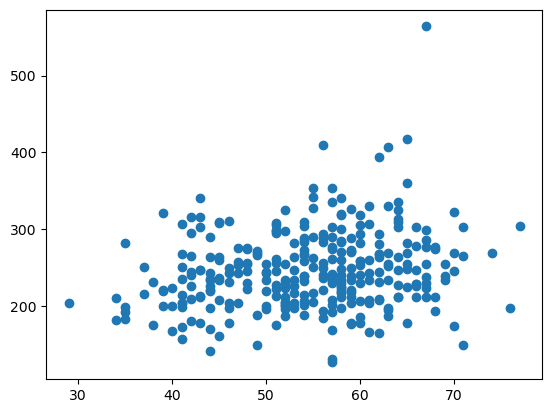

In [50]:
plt.scatter(x=df['age'], y=df['chol'])

We can optionally add labels and title to the visualization

Text(0.5, 0, 'age')

Text(0, 0.5, 'cholesterol')

Text(0.5, 1.0, 'Cholesterol levels by age')

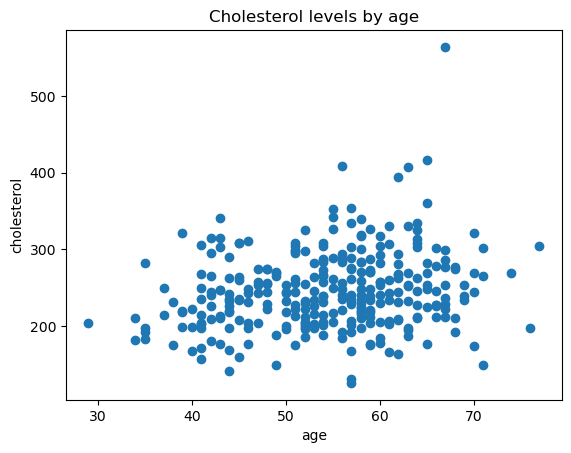

In [53]:
plt.scatter(x=df['age'], y=df['chol'])
plt.xlabel('age')
plt.ylabel('cholesterol')
plt.title('Cholesterol levels by age')

## Barplots

These are great to display the counts of categorical variables

In [55]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
192,43,male,asymptomatic,132,247,1,left ventricular hypertrophy,143,1,0.1,fat,NaN,reversible defect,>50%
189,69,male,non-anginal pain,140,254,0,left ventricular hypertrophy,146,0,2.0,fat,3.0,reversible defect,>50%
0,63,male,typical angina,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0.0,fixed defect,<50%


Let's study the distribution of restecg

In [56]:
df['restecg'].value_counts()

restecg
normal                          151
left ventricular hypertrophy    148
ST-T wave abnormality             4
Name: count, dtype: int64

We can plot this

<BarContainer object of 3 artists>

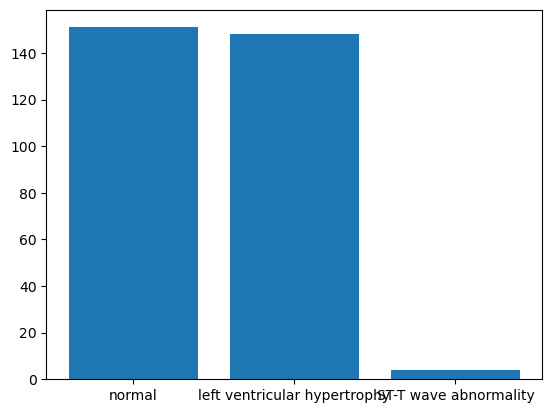

In [62]:
result = df['restecg'].value_counts()

plt.bar(x=result.index, height=result.values)

## histograms

In [63]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
id,,,,,,,,,,,,,,
192,43,male,asymptomatic,132,247,1,left ventricular hypertrophy,143,1,0.1,fat,NaN,reversible defect,>50%
189,69,male,non-anginal pain,140,254,0,left ventricular hypertrophy,146,0,2.0,fat,3.0,reversible defect,>50%
0,63,male,typical angina,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0.0,fixed defect,<50%


(array([ 1., 10., 33., 38., 37., 60., 64., 43., 14.,  3.]),
 array([29. , 33.8, 38.6, 43.4, 48.2, 53. , 57.8, 62.6, 67.4, 72.2, 77. ]),
 <BarContainer object of 10 artists>)

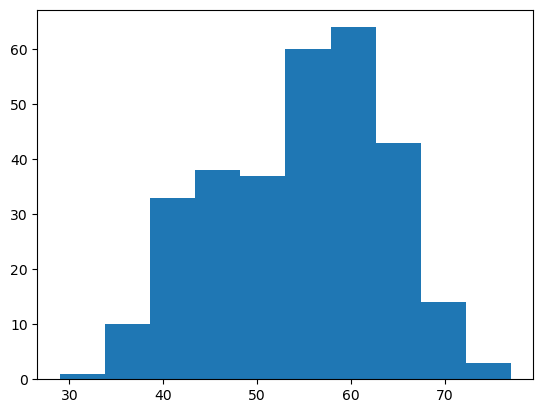

In [64]:
plt.hist(df['age'])

We can control the number of bins

(array([ 1.,  0.,  0.,  6.,  0.,  4.,  7., 10., 16., 11., 15., 12.,  5.,
        19., 13., 24., 19., 17., 33., 12., 19., 19.,  8., 16.,  4.,  7.,
         3.,  0.,  1.,  2.]),
 array([29. , 30.6, 32.2, 33.8, 35.4, 37. , 38.6, 40.2, 41.8, 43.4, 45. ,
        46.6, 48.2, 49.8, 51.4, 53. , 54.6, 56.2, 57.8, 59.4, 61. , 62.6,
        64.2, 65.8, 67.4, 69. , 70.6, 72.2, 73.8, 75.4, 77. ]),
 <BarContainer object of 30 artists>)

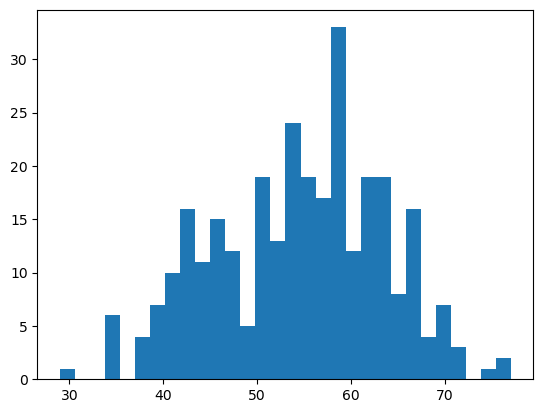

In [65]:
plt.hist(df['age'], bins= 30)

![](media/dog.jpeg)